In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ev-battery-charging-and-thermal-runaway-dataset/EV_Battery_Charging_TR_Dataset_with_Notes.csv


In [42]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Step 1: Importing Required Libraries

In this step, we import all the necessary Python libraries required for data analysis and machine learning.

- **NumPy** and **Pandas** are used for data handling and numerical operations.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **Scikit-learn** is used to build and evaluate machine learning models.

These libraries help us perform preprocessing, model training, evaluation, and visualization efficiently.

In [43]:
df = pd.read_csv("/kaggle/input/ev-battery-charging-and-thermal-runaway-dataset/EV_Battery_Charging_TR_Dataset_with_Notes.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Timestamp,ChargerID,CellID,ChargingStage,PackVoltage_V,CellVoltage_V,DemandVoltage_V,ChargeCurrent_A,DemandCurrent_A,SOC_%,...,InternalResistance_mOhm,StateOfHealth_%,VibrationLevel_mg,MoistureDetected,BMS_Status,ChargePower_kW,Pressure_kPa,TR_Probability,EventFlag,Notes
0,9/3/2025 8:00,CH5,CELL22,End_Of_Charge,326.69,3.633,328.48,84.75,82.87,57.00,...,12.54,87.22,27.80,True,Critical,27.69,118.08,0.874,Alarm,Rapid temp rise; High internal resistance; Moi...
1,9/3/2025 8:01,CH7,CELL7,End_Of_Charge,336.91,4.101,332.69,75.11,72.66,83.07,...,5.88,90.72,43.07,True,Warning,25.31,98.74,0.997,Runaway,Critical thermal runaway risk; Moisture detected
2,9/3/2025 8:02,CH5,CELL31,Recharge,333.47,4.160,338.13,29.16,30.82,63.16,...,4.13,83.16,38.62,False,Warning,9.72,109.72,0.792,Alarm,Normal operation
3,9/3/2025 8:03,CH1,CELL23,Handshake,391.13,3.928,390.90,26.96,30.15,56.46,...,13.72,84.63,46.85,False,OK,10.54,110.82,1.000,Runaway,Critical thermal runaway risk; Rapid temp rise...
4,9/3/2025 8:04,CH2,CELL32,End_Of_Charge,301.56,4.052,297.76,19.61,22.99,9.59,...,3.06,98.17,2.71,False,OK,5.91,94.57,0.688,Warning,Rapid temp rise


# Step 2: Loading the Dataset

In this step, we load the EV battery charging dataset into a Pandas DataFrame.

The dataset contains real-time battery charging parameters such as voltage, current, temperature, SOC, and safety-related indicators.

Loading the dataset allows us to inspect, clean, and analyze the data before building machine learning models.

In [44]:
print(df.shape)

(500, 24)


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                500 non-null    object 
 1   ChargerID                500 non-null    object 
 2   CellID                   500 non-null    object 
 3   ChargingStage            500 non-null    object 
 4   PackVoltage_V            500 non-null    float64
 5   CellVoltage_V            500 non-null    float64
 6   DemandVoltage_V          500 non-null    float64
 7   ChargeCurrent_A          500 non-null    float64
 8   DemandCurrent_A          500 non-null    float64
 9   SOC_%                    500 non-null    float64
 10  MaxTemp_C                500 non-null    float64
 11  MinTemp_C                500 non-null    float64
 12  AvgTemp_C                500 non-null    float64
 13  AmbientTemp_C            500 non-null    float64
 14  InternalResistance_mOhm  5

In [46]:
print(df.describe())

       PackVoltage_V  CellVoltage_V  DemandVoltage_V  ChargeCurrent_A  \
count     500.000000     500.000000       500.000000       500.000000   
mean      346.386840       3.902852       346.390600        58.927500   
std        28.730825       0.169236        28.727904        33.950413   
min       300.070000       3.603000       295.600000         0.230000   
25%       320.937500       3.759250       321.990000        29.212500   
50%       346.065000       3.905500       345.920000        58.640000   
75%       370.295000       4.047250       369.975000        87.732500   
max       399.970000       4.199000       402.560000       119.900000   

       DemandCurrent_A      SOC_%   MaxTemp_C  MinTemp_C  AvgTemp_C  \
count       500.000000  500.00000  500.000000  500.00000  500.00000   
mean         59.116640   50.85144   52.837480   50.47784   51.65766   
std          34.001186   29.03999   15.873626   15.95003   15.89573   
min          -3.320000    0.12000   25.090000   20.37000  

In [47]:
df = df.drop(columns=["Timestamp", "Notes"])
print("Dropped Timestamp and Notes")

Dropped Timestamp and Notes


# Step 3: Data Cleaning – Removing Irrelevant Columns

Here, we remove the 'Timestamp' and 'Notes' columns.

- The **Timestamp** column is not required for this current machine learning model.
- The **Notes** column contains text data, which is not directly usable in numerical ML models.

Removing unnecessary columns helps simplify the dataset and improve model performance.

In [48]:
le = LabelEncoder()

categorical_cols = ["ChargerID", "CellID", "ChargingStage",
                    "BMS_Status", "MoistureDetected", "EventFlag"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding Completed")

Encoding Completed


# Step 4: Encoding Categorical Variables

Machine learning models cannot process text-based categorical values directly.

In this step, we convert categorical features such as:
- ChargingStage
- BMS_Status
- MoistureDetected
- EventFlag

into numerical format using Label Encoding.

This ensures that all input features are in numeric form, making them suitable for model training.

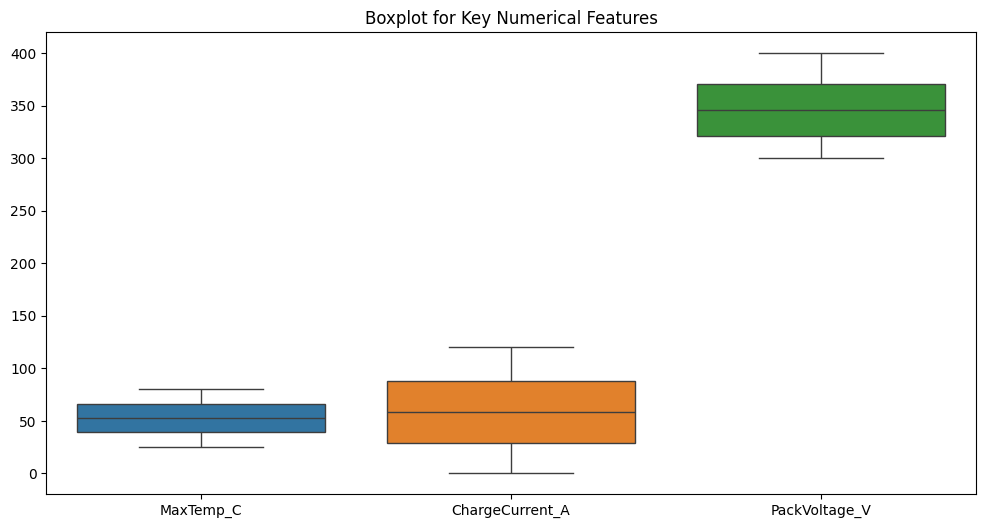

In [49]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[["MaxTemp_C", "ChargeCurrent_A", "PackVoltage_V"]])
plt.title("Boxplot for Key Numerical Features")
plt.show()

# Step 5: Visualizing Data Distribution using Boxplot

In this step, we use boxplots to analyze the distribution of important numerical features such as:

- Maximum Temperature
- Charging Current
- Pack Voltage

Boxplots help us identify:
- Median values
- Data spread
- Presence of potential outliers

This helps in understanding the safety behavior of battery parameters.

In [50]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    print(f"{column} Outliers:", len(outliers))

detect_outliers("MaxTemp_C")
detect_outliers("ChargeCurrent_A")
detect_outliers("PackVoltage_V")

MaxTemp_C Outliers: 0
ChargeCurrent_A Outliers: 0
PackVoltage_V Outliers: 0


# Step 6: Outlier Detection using IQR Method

Here, we detect potential outliers using the Interquartile Range (IQR) method.

Outliers represent extreme values that may indicate abnormal battery behavior such as:
- Sudden temperature spikes
- Excessive charging current
- Voltage irregularities

Identifying outliers is important for safety analysis and improving model robustness.

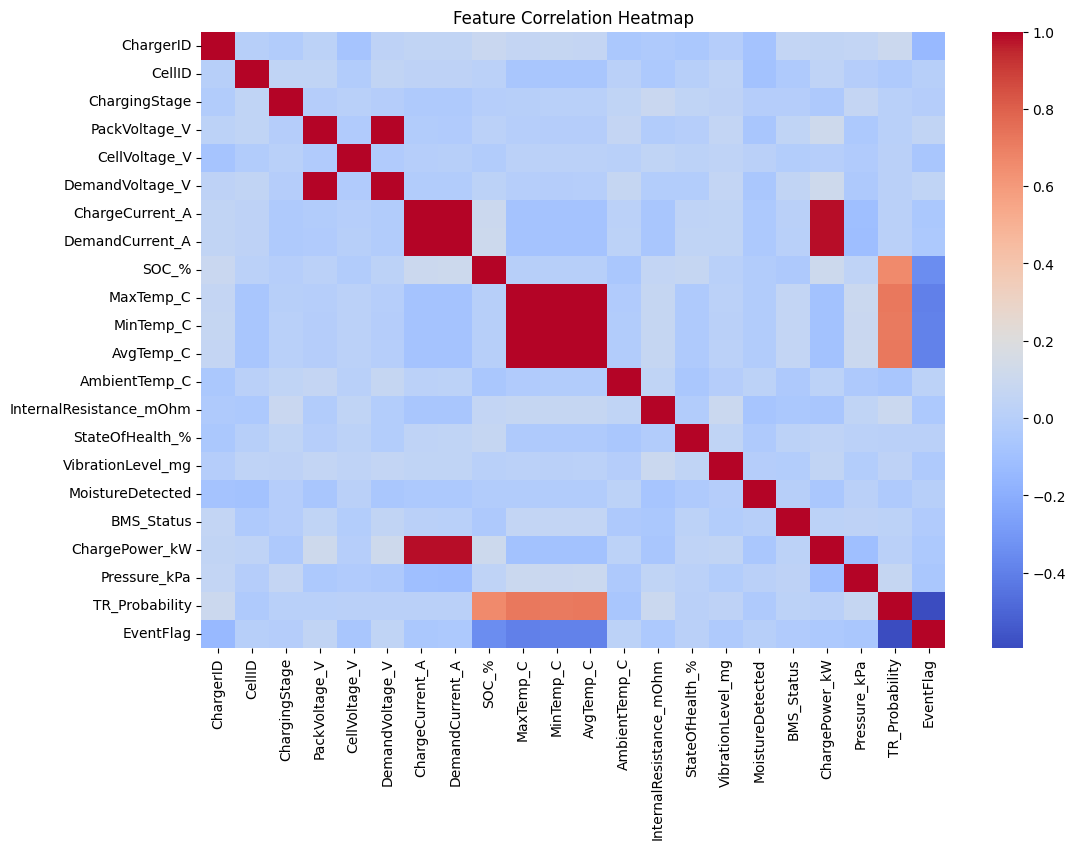

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 7: Feature Correlation Analysis using Heatmap

In this step, we analyze the correlation between different numerical features using a correlation heatmap.

Correlation values range from -1 to +1:

- +1 indicates strong positive correlation  
- -1 indicates strong negative correlation  
- 0 indicates no correlation  

This analysis helps us understand:

- Which battery parameters are strongly related to each other  
- Which features influence Thermal Runaway Probability  
- Whether multicollinearity exists between input variables  

Understanding feature correlation helps in better feature selection and model interpretation.

In [52]:
#PART 1 — CLASSIFICATION

X = df.drop("EventFlag", axis=1)
y = df["EventFlag"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [54]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Classifier Trained")

Classifier Trained


# Step 8: Building Classification Model – Event Flag Prediction

In this step, we build a Random Forest Classifier to predict the EventFlag.

The EventFlag represents different battery safety conditions such as Normal, Warning, or Alarm.

The dataset is divided into training and testing sets, and the model is trained using the training data.

Random Forest is used because it is robust, reduces overfitting, and performs well on structured datasets.

Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        42
           1       1.00      1.00      1.00        25
           2       1.00      0.97      0.98        29
           3       1.00      1.00      1.00         4

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



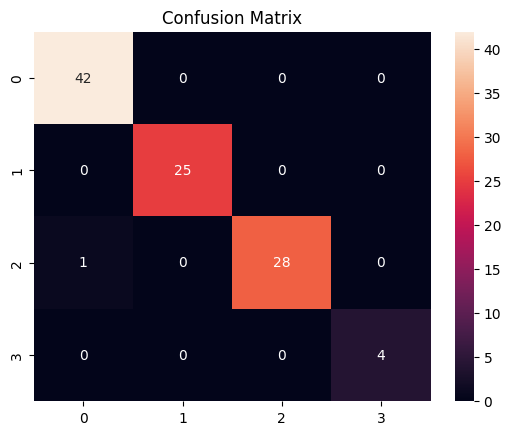

In [55]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# Step 9: Evaluating Classification Model

Here, we evaluate the model using:

- Accuracy Score
- Classification Report (Precision, Recall, F1-score)
- Confusion Matrix

These metrics help us understand how well the model predicts battery safety events and whether it misclassifies critical conditions.

In [56]:
#PART 2 — REGRESSION
X_reg = df.drop(["TR_Probability", "EventFlag"], axis=1)
y_reg = df["TR_Probability"]

In [57]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [58]:
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

print("Regressor Trained")

Regressor Trained


# Step 10: Building Regression Model – Thermal Runaway Probability Prediction

In this step, we build a Random Forest Regressor to predict the Thermal Runaway Probability.

This model predicts a continuous value between 0 and 1, indicating the likelihood of a thermal runaway event.

We removed EventFlag from the regression input features to avoid data leakage and ensure realistic prediction.

In [59]:
y_pred_r = reg.predict(X_test_r)

print("R2 Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))

R2 Score: 0.9784771189723573
MAE: 0.02034670000000002
RMSE: 0.02670673939289483


# Step 11: Evaluating Regression Model

The regression model is evaluated using:

- R² Score – Measures how well the model explains variance in the data.
- MAE (Mean Absolute Error) – Average prediction error.
- RMSE (Root Mean Squared Error) – Penalizes larger errors.

A high R² score and low error values indicate strong predictive performance.

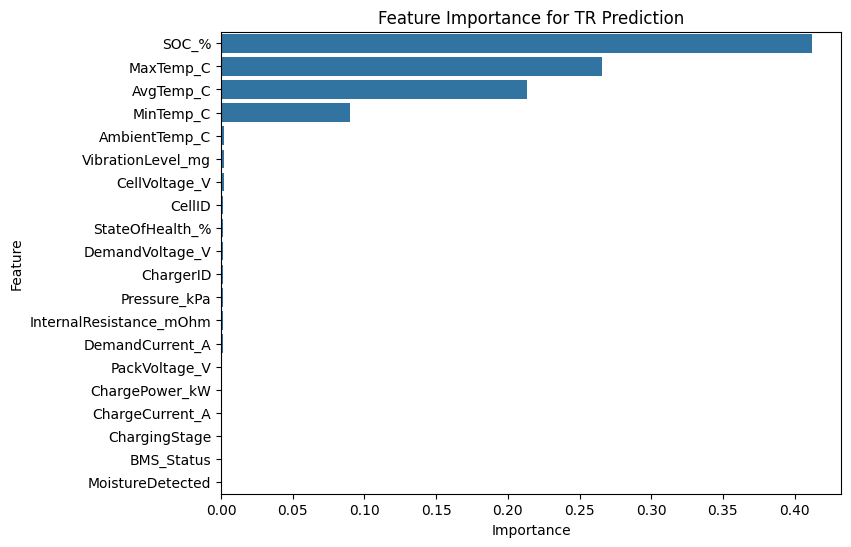

In [60]:
#Feature Importance
importances = reg.feature_importances_
feature_names = X_reg.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance for TR Prediction")
plt.show()

# Step 12: Feature Importance Analysis

In this step, we analyze feature importance using the trained Random Forest model.

Feature importance helps identify which battery parameters most influence thermal runaway probability.

Understanding important features such as temperature, current, and voltage helps improve battery safety monitoring systems.